# Parameters

In [1]:
from pathlib import Path
import sys 

repo_root = Path.cwd().resolve()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

%reload_ext autoreload
%autoreload 2

output_dir = Path("../output")

### Parameters

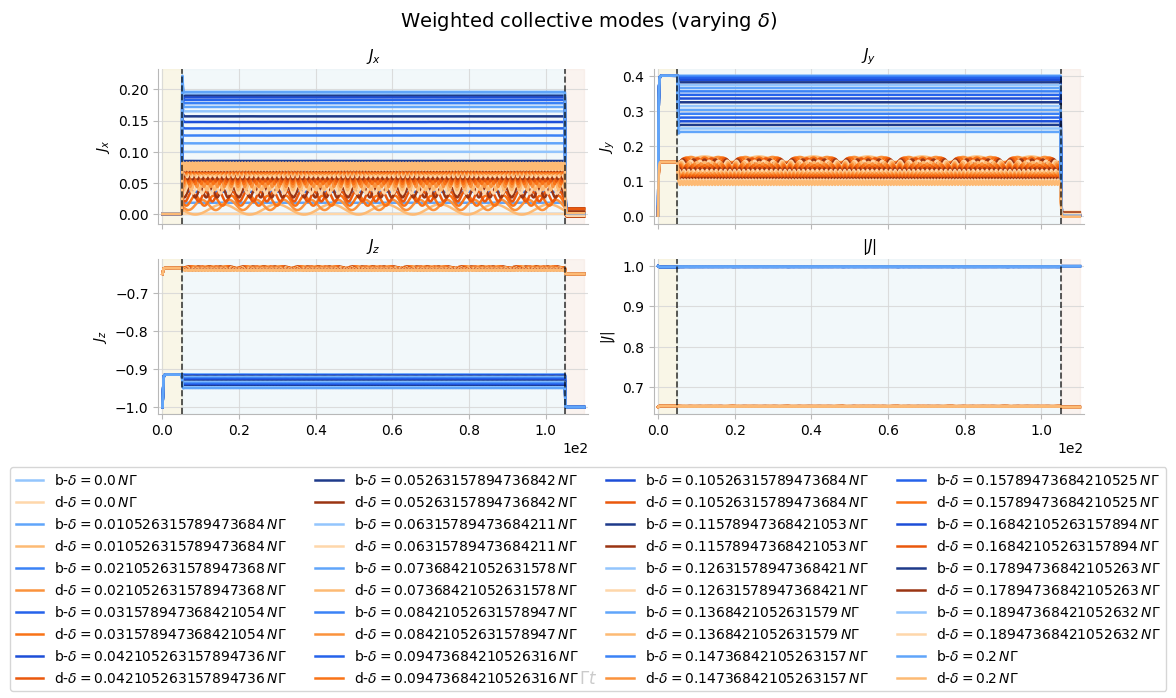

In [2]:
import numpy as np

from common.utils.parameters import (
    omega_c,
    scaled_N_Gamma,
    mcwf_dt_from_scales,
)
from common.utils.phases import default_three_phase_protocol
from solvers.mfe import compute_mfe_j_moments, solve_mfe
from parser.mfe import MFESolverParameters
from common.plotting import plot_harmonic_sweep, plot_spin_components

from parser.moments import MomentSeries, SimulationMetadata
from post_analysis import (
    compute_harmonic_analysis,
    compute_j_modes,
    extract_family_phase_series,
)


delta_factor_list = np.linspace(0.0, 0.20, 20)
Ni_list = (5, 10, 15, 20)

spectral_components = ("x", "y", "z")
spectral_delta_factors = []

dark_fundamental_frequency_sweeps = {
    component: [] for component in spectral_components
}
dark_thd_sweeps = {component: [] for component in spectral_components}
dark_rms_amplitude_sweeps = {
    component: [] for component in spectral_components
}
dark_offset_sweeps = {component: [] for component in spectral_components}

axes = None
for i,delta_factor in enumerate(delta_factor_list):
# for i,Ni_candidate in enumerate(Ni_list):
    # common fixed
    Gamma = 1; num_snapshots=10000
    # param
    dN = 0
    # Ni = [Ni_candidate,2*Ni_candidate]
    Ni = [10,30]
    omega_i = [0.7]
    ntraj = 1000
    # Model and parameters
    Omega_factor = 0.1
    Omega0 = scaled_N_Gamma(Omega_factor, sum(Ni), Gamma)
    # delta_factor = 0.02
    delta0 = scaled_N_Gamma(delta_factor, sum(Ni), Gamma)

    phase_protocol = default_three_phase_protocol(
        durations=(5, 100, 5),
        delta0=delta0,
        Omega0=Omega0,
    )
    simulation_metadata = SimulationMetadata(
        Ni=tuple(Ni),
        omega_i=tuple(omega_i),
        Gamma=Gamma,
        phase_protocol=phase_protocol,
    )

    # Omega_c = omega_c(sum(Ni) // 2, Gamma)
    # print(f"Omega0 = {Omega0}")
    # print(f"Omega/Omega_c ratio = {Omega0 / Omega_c}")
    # print(f"delta0 = {delta0}")


    # moment initialization
    mfe_moments = MomentSeries(
        num_snapshots=num_snapshots,
        metadata=simulation_metadata,
    )

    # Define method parameters and solve using mean-field equations
    mfe_parameters = MFESolverParameters(
        Ni=simulation_metadata.Ni,
        omega_i=simulation_metadata.omega_groups,
        Gamma=simulation_metadata.Gamma,
        phase_protocol=simulation_metadata.phase_protocol,
    )
    mfe_result = solve_mfe(
        mfe_parameters,
        t_eval=mfe_moments.t,
    )

    # compute moments
    mfe_moments.J = compute_mfe_j_moments(mfe_result)

    mfe_moments.J_modes = compute_j_modes(
        mfe_moments.J.t,
        mfe_moments.J.nx_groups,
        mfe_moments.J.ny_groups,
        mfe_moments.J.nz_groups,
        populations=mfe_moments.J.N_j_groups,
        omega_groups=mfe_moments.metadata.omega_groups,
    )

    j_modes = mfe_moments.J_modes

    phase_2_t, phase_2_series = extract_family_phase_series(
        j_modes.t,
        (j_modes.dark.x, j_modes.dark.y, j_modes.dark.z),
        phase_protocol,
        family_phase_index=1,
    )
    harmonic_analysis = compute_harmonic_analysis(
        phase_2_t,
        phase_2_series,
    )
    if harmonic_analysis is None:
        print(f"Warning: spectral analysis skipped for delta={delta0}.")
    else:
        spectral_delta_factors.append(delta_factor)
        for component, dark_signal in zip(
            spectral_components, harmonic_analysis.signals
        ):
            dark_fundamental_frequency_sweeps[component].append(
                dark_signal.fundamental_frequency
            )
            dark_thd_sweeps[component].append(
                dark_signal.total_harmonic_distortion
            )
            dark_rms_amplitude_sweeps[component].append(
                dark_signal.rms_amplitude
            )
            dark_offset_sweeps[component].append(dark_signal.offset)

    mode_vectors = (j_modes.bright, j_modes.dark)
    fig, axes = plot_spin_components(
        j_modes.t,
        tuple(mode.x for mode in mode_vectors),
        tuple(mode.y for mode in mode_vectors),
        tuple(mode.z for mode in mode_vectors),
        tuple(mode.length for mode in mode_vectors),
        phase_protocol=mfe_moments.metadata.phase_protocol,
        labels=(
            rf"b-$\delta={delta_factor}\,N\Gamma$",
            rf"d-$\delta={delta_factor}\,N\Gamma$",
        ),
        # labels=(
        #     rf"sym $N={int(sum(Ni))}$",
        #     rf"asym $N={int(sum(Ni))}$",
        # ),
        colour_family_index=None,
        shade_index=i,
        linestyle="-",
        axes=axes,
        title=r"Weighted collective modes (varying $\delta$)",
        #output_path=f"{output_dir}/bright_dark_modes/varying_delt",
    )

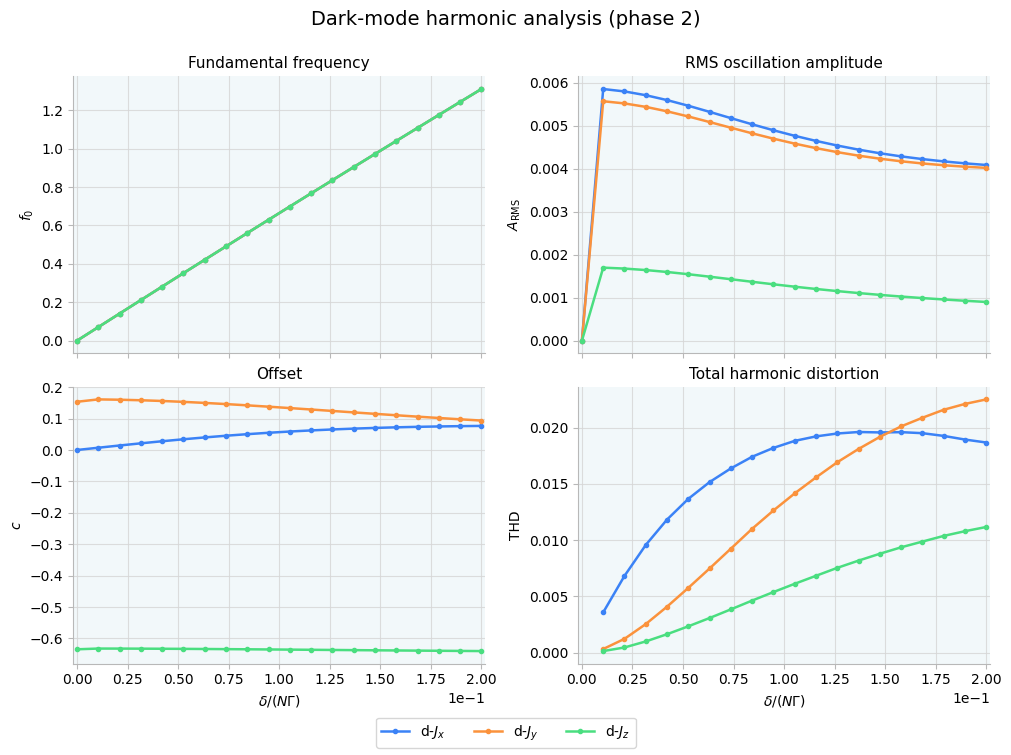

In [3]:
fig, axes = plot_harmonic_sweep(
    spectral_delta_factors,
    tuple(
        dark_fundamental_frequency_sweeps[component]
        for component in spectral_components
    ),
    tuple(dark_thd_sweeps[component] for component in spectral_components),
    tuple(
        dark_rms_amplitude_sweeps[component]
        for component in spectral_components
    ),
    tuple(dark_offset_sweeps[component] for component in spectral_components),
    labels = (r"d-$J_x$", r"d-$J_y$", r"d-$J_z$"),
    parameter_label=r"$\delta/(N\Gamma)$",
    family_phase_index=1,
    colour_family_index=None,
    shade_index=2,
    marker=".",
    title="Dark-mode harmonic analysis (phase 2)",
)